# QRC time-series prediction — true vs predicted, on a Lyapunov-time axis

For each **dataset** we drive the quantum reservoir with the (leakage-guarded)
history and forecast one step ahead, once per reservoir **Hamiltonian**
(`ising`, `xxz_hx`). Each panel overlays the held-out **true** series against
each model's **prediction**.

The time axis of each panel is rescaled into **Lyapunov times** — multiples of
the dataset's own $T_\lambda = 1/\lambda_1$, the interval over which an initial
error grows by a factor $e$. This makes the horizons comparable across series
that live on wildly different clocks (months vs hours) and states the forecast
in the only units chaos cares about.

**Before trusting any $\lambda_1$ we validate the estimator on the Lorenz
butterfly**, whose largest Lyapunov exponent is known ($\lambda_1 \approx
0.9056$). The datasets are scalar records, so we use the single-trajectory
Rosenstein estimator from `lyapunov.py`; the same settings that recover Lorenz
are then applied to the data.

Engine, loader, sweeps and the Lyapunov code all live in this folder
(`qrc_core.py`, `data_loader.py`, `experiments.py`, `lyapunov.py`). Run
top-to-bottom with the `qdrug` kernel.

## 1. Configuration and the Lyapunov helper

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import experiments as E
from data_loader import load
from lyapunov import lyapunov_rosenstein, fit_growth_window, lyapunov_time

# --- forecasting setup -------------------------------------------------------
DATASETS = ["nino34", "nino12", "tao", "nyc", "solar", "load"]
MODELS   = ["ising", "xxz_hx"]
RES_KW   = dict(n_qubits=5, virtual_nodes=4, dt=2.0, seed=7)
J, HX    = 1.0, 1.0        # fixed hyperparameters (tune per dataset via experiments.scan)
HORIZON  = 1
MAX_LEN  = 2000            # cap length so the O(4^n) reservoir stays fast
COLORS   = {"ising": "#d62728", "xxz_hx": "#2ca02c"}

# --- Lyapunov estimator settings (validated on Lorenz below) -----------------
# The single-trajectory Rosenstein curve has a fast initial re-orientation phase
# before the true exponential stretch; fitting the 35%-75% fractional-rise
# window skips that transient. These fractions recover Lorenz-63 to ~10%.
LO, HI = 0.35, 0.75

def rosenstein_lambda(x, dt, *, max_n=2500, horizon=None, lo=LO, hi=HI):
    """Largest Lyapunov exponent of a scalar series (Rosenstein + tuned window).

    Returns a dict with the exponent `lam` (1/time_unit), Lyapunov time `Tlyap`,
    the embedding `(m, tau)`, and the divergence curve `(t, curve, win)`.
    """
    n_eff = min(len(x), max_n)
    if horizon is None:
        horizon = max(20, min(n_eff // 3, 400))
    t, curve, (m, tau) = lyapunov_rosenstein(x, dt=dt, max_n=max_n, horizon=horizon)
    slope, win = fit_growth_window(t, curve, lo_frac=lo, hi_frac=hi)
    return {"lam": slope, "Tlyap": lyapunov_time(slope), "m": m, "tau": tau,
            "t": t, "curve": curve, "win": win}

print("datasets:", DATASETS, "| models:", MODELS)

datasets: ['nino34', 'nino12', 'tao', 'nyc', 'solar', 'load'] | models: ['ising', 'xxz_hx']


## 2. Validate the estimator on the Lorenz butterfly

We integrate the Lorenz-63 system ($\sigma=10,\ \rho=28,\ \beta=8/3$), take the
scalar $x(t)$ as the observable — exactly the situation of a one-column dataset —
and run the **same** `rosenstein_lambda` we will use on the data. The recovered
$\hat\lambda_1$ should land near the textbook $0.9056$.

The divergence curve rises through a fast re-orientation phase, then a straight
**exponential** stretch (slope $=\lambda_1$), then saturates at the attractor
size; the fit window must sit on the straight middle.

Lorenz-63:  lambda_hat = 0.9976 /t   (true 0.9056)   error +10.2%   [m=3, tau=16]


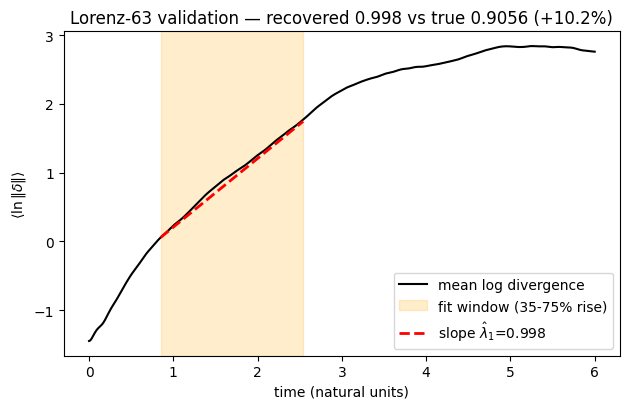

In [2]:
from scipy.integrate import solve_ivp

def lorenz(t, s, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = s
    return [sigma*(y-x), x*(rho-z)-y, x*y-beta*z]

LYAP_TRUE = 0.9056
dt_l = 0.01
sol = solve_ivp(lorenz, [0, 140], [1.0, 1.0, 1.0],
                t_eval=np.arange(0, 140, dt_l), rtol=1e-9, atol=1e-9)
x_l = sol.y[0][2000:]                       # drop the 20-time-unit transient

est = rosenstein_lambda(x_l, dt_l, max_n=4000, horizon=600)
lam_hat = est["lam"]
err = lam_hat / LYAP_TRUE - 1.0
print(f"Lorenz-63:  lambda_hat = {lam_hat:.4f} /t   (true {LYAP_TRUE})   "
      f"error {err:+.1%}   [m={est['m']}, tau={est['tau']}]")
assert 0.6 < lam_hat < 1.3, "estimator off by more than the method's known band"

# Visualise the divergence curve and the fitted exponential region.
t, curve, (lo_i, hi_i) = est["t"], est["curve"], est["win"]
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(t, curve, color="k", lw=1.5, label="mean log divergence")
ax.axvspan(t[lo_i], t[hi_i], color="orange", alpha=0.20, label="fit window (35-75% rise)")
xx = t[lo_i:hi_i + 1]
ax.plot(xx, lam_hat * xx + (curve[lo_i] - lam_hat * t[lo_i]), "r--", lw=2,
        label=fr"slope $\hat\lambda_1$={lam_hat:.3f}")
ax.set_xlabel("time (natural units)")
ax.set_ylabel(r"$\langle \ln \Vert \delta \Vert \rangle$")
ax.set_title(f"Lorenz-63 validation — recovered {lam_hat:.3f} vs true {LYAP_TRUE} ({err:+.1%})")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Run the QRC forecasts

For every `(dataset, model)` build a reservoir at `(J, hx)`, drive it with the
series, and keep the held-out true/predicted tail. `y_true` is identical across
models for a dataset (same data and split), so we store it once.

In [3]:
results = {}
for ds in DATASETS:
    s = load(ds)
    x = s.x[:MAX_LEN] if MAX_LEN else s.x
    idx = s.index[:MAX_LEN] if s.index is not None else None
    results[ds] = {"name": s.name, "unit": s.unit, "time_unit": s.time_unit,
                   "dt": s.dt, "index": idx, "models": {}}
    for m in MODELS:
        res = E.make_reservoir(m, J, HX, **RES_KW)
        r = E.forecast_series(x, res, horizon=HORIZON)
        results[ds]["models"][m] = r
        print(f"{ds:8s} {m:7s}  NMSE={r['nmse']:.4f}   test N={len(r['y_true'])}")


nino34   ising    NMSE=0.0577   test N=246


nino34   xxz_hx   NMSE=0.0496   test N=246
nino12   ising    NMSE=0.0718   test N=190


nino12   xxz_hx   NMSE=0.0515   test N=190


tao      ising    NMSE=0.0877   test N=475


tao      xxz_hx   NMSE=0.1532   test N=475


...

nyc      xxz_hx   NMSE=0.1760   test N=570


solar    ising    NMSE=0.0221   test N=570


solar    xxz_hx   NMSE=0.0213   test N=570


load     ising    NMSE=0.0416   test N=570


load     xxz_hx   NMSE=0.0485   test N=570


## 4. Lyapunov exponent of each dataset

The same validated `rosenstein_lambda`, now on each real series (estimated on
the full record, not the length-capped forecast slice). $\lambda_1$ is in
$1/\text{time\_unit}$; $T_\lambda = 1/\lambda_1$ is the predictability horizon
the dynamics permit. **These single-trajectory values are upper bounds with
~factor-2 uncertainty** (see `lyapunov.py`), and seasonal series inflate them —
read them as scale, not measurement.

In [4]:
lyap = {}
for ds in DATASETS:
    s = load(ds)
    est = rosenstein_lambda(s.x, s.dt)
    lyap[ds] = est
    print(f"{ds:8s}  lambda_1 = {est['lam']:.4g} /{s.time_unit:<4s} "
          f"T_lambda = {est['Tlyap']:.4g} {s.time_unit:<4s} "
          f"[m={est['m']}, tau={est['tau']}]")


nino34    lambda_1 = 0.1522 /yr   T_lambda = 6.572 yr   [m=7, tau=8]
nino12    lambda_1 = 0.6068 /yr   T_lambda = 1.648 yr   [m=4, tau=4]


tao       lambda_1 = 0.01267 /day  T_lambda = 78.93 day  [m=5, tau=46]


nyc       lambda_1 = 0.05336 /day  T_lambda = 18.74 day  [m=6, tau=11]


solar     lambda_1 = 0.0297 /h    T_lambda = 33.67 h    [m=9, tau=12]


load      lambda_1 = 0.04573 /h    T_lambda = 21.87 h    [m=4, tau=5]


## 5. True vs predicted — time axis in Lyapunov times

Each panel's horizontal axis is $t\,\lambda_1$: the number of $e$-folding times
elapsed since the start of the held-out window. $\lambda_1$ (and $T_\lambda$)
appear in each legend. Black is truth; each colour is a Hamiltonian's forecast.

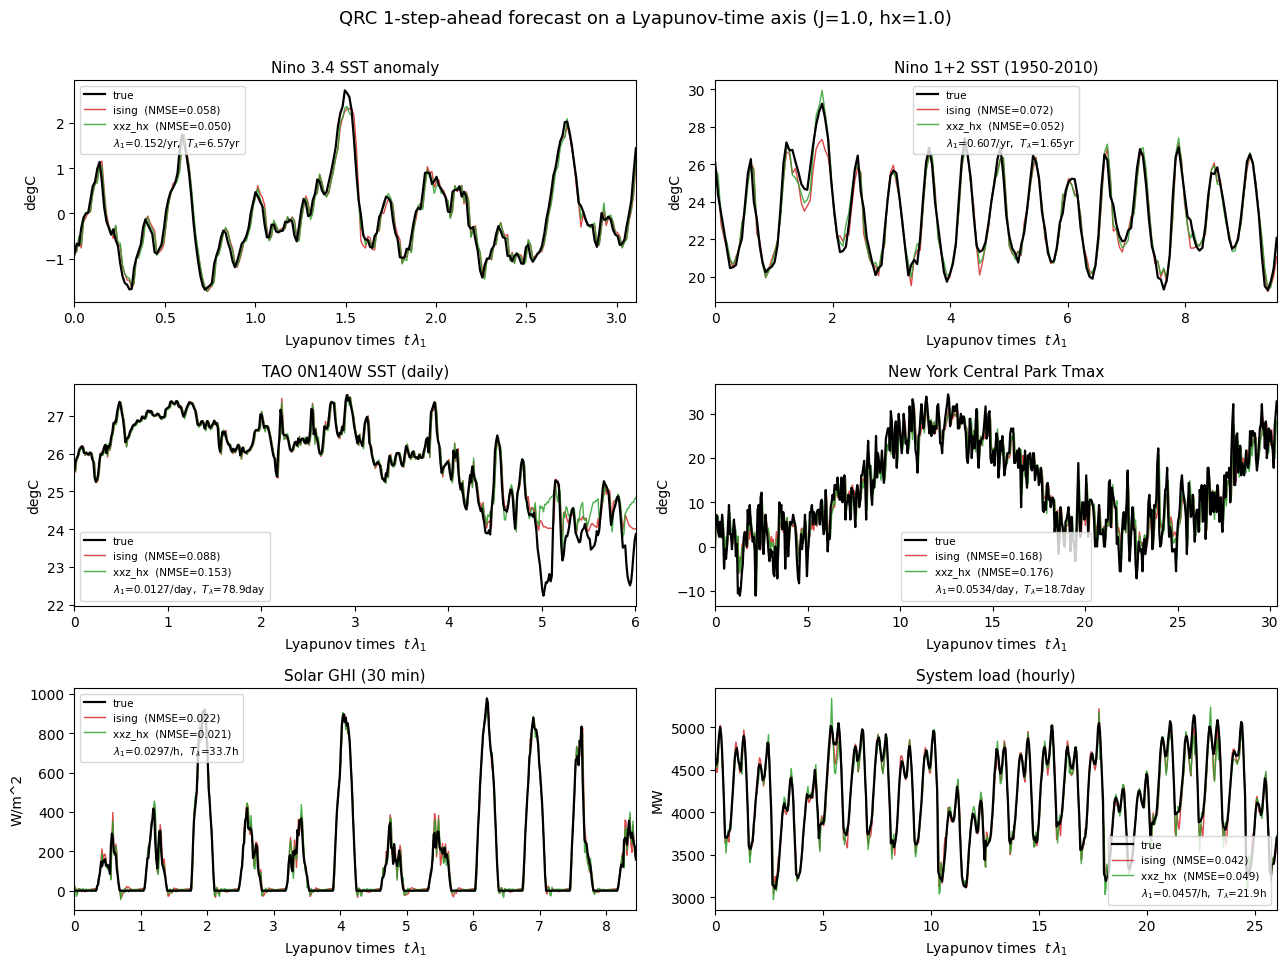

In [5]:
ncols = 2
nrows = int(np.ceil(len(DATASETS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, ds in zip(axes, DATASETS):
    R = results[ds]
    ref = next(iter(R["models"].values()))          # any model shares y_true/test_pos
    pos = ref["test_pos"]
    lam = lyap[ds]["lam"]
    tu = R["time_unit"]

    # elapsed physical time since the test window starts, then -> Lyapunov times
    elapsed = (pos - pos[0]) * R["dt"]
    if np.isfinite(lam) and lam > 0:
        xaxis = elapsed * lam                        # t * lambda_1  (dimensionless)
        xlabel = r"Lyapunov times  $t\,\lambda_1$"
        lam_lbl = fr"$\lambda_1$={lam:.3g}/{tu},  $T_\lambda$={lyap[ds]['Tlyap']:.3g}{tu}"
    else:
        xaxis = elapsed                              # fallback: physical time
        xlabel = f"time ({tu})"
        lam_lbl = r"$\lambda_1 \leq 0$ (no exp. horizon)"

    ax.plot(xaxis, ref["y_true"], color="black", lw=1.6, label="true", zorder=3)
    for m in MODELS:
        rm = R["models"][m]
        ax.plot(xaxis, rm["y_pred"], color=COLORS[m], lw=1.0, alpha=0.85,
                label=f"{m}  (NMSE={rm['nmse']:.3f})")
    ax.plot([], [], " ", label=lam_lbl)              # lambda_1 as a legend entry
    ax.set_title(R["name"], fontsize=11)
    ax.set_xlabel(xlabel)
    if R["unit"]:
        ax.set_ylabel(R["unit"])
    ax.legend(fontsize=7.5, loc="best")
    ax.margins(x=0)

for ax in axes[len(DATASETS):]:
    ax.axis("off")

fig.suptitle(f"QRC {HORIZON}-step-ahead forecast on a Lyapunov-time axis "
             f"(J={J}, hx={HX})", y=1.003, fontsize=13)
fig.tight_layout()
plt.show()

## 6. NMSE summary — which Hamiltonian wins on each dataset

In [6]:
tbl = pd.DataFrame(
    {m: [results[ds]["models"][m]["nmse"] for ds in DATASETS] for m in MODELS},
    index=DATASETS,
)
tbl["best"] = tbl[MODELS].idxmin(axis=1)
tbl["lambda_1"] = [lyap[ds]["lam"] for ds in DATASETS]
tbl["T_lambda"] = [lyap[ds]["Tlyap"] for ds in DATASETS]
print(tbl.round(4).to_string())
tbl.round(4)

         ising  xxz_hx    best  lambda_1  T_lambda
nino34  0.0577  0.0496  xxz_hx    0.1522    6.5722
nino12  0.0718  0.0515  xxz_hx    0.6068    1.6481
tao     0.0877  0.1532   ising    0.0127   78.9251
nyc     0.1677  0.1760   ising    0.0534   18.7415
solar   0.0221  0.0213  xxz_hx    0.0297   33.6740
load    0.0416  0.0485   ising    0.0457   21.8691


,ising,xxz_hx,best,lambda_1,T_lambda
nino34,0.0577,0.0496,xxz_hx,0.1522,6.5722
nino12,0.0718,0.0515,xxz_hx,0.6068,1.6481
tao,0.0877,0.1532,ising,0.0127,78.9251
nyc,0.1677,0.1760,ising,0.0534,18.7415
solar,0.0221,0.0213,xxz_hx,0.0297,33.6740
load,0.0416,0.0485,ising,0.0457,21.8691


## 7. Notes & caveats

- **Estimator provenance.** `rosenstein_lambda` is single-trajectory: an upper
  bound on $\lambda_1$ with ~factor-2 uncertainty, and it inflates on strongly
  seasonal records (every climate series here has an annual cycle). The Lorenz
  check bounds the *method* error (~10%); it does not certify each dataset's
  number. For a reliable $\lambda_1$ you need an ensemble of realizations
  (`lyapunov.lyapunov_ensemble`), which real single records do not provide.
- **Why a Lyapunov-time axis.** A fixed NMSE means very different things at
  0.1 vs 10 Lyapunov times ahead. Plotting against $t\,\lambda_1$ shows how far
  into the system's own predictability horizon the forecast reaches.
- **Tuning.** Panels use one fixed $(J, h_x)$. Use
  `experiments.forecast_nmse_grid` + `experiments.peak(mode="min")` to pick each
  dataset's best hyperparameters, then re-run.